In [961]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import scipy.stats as stats

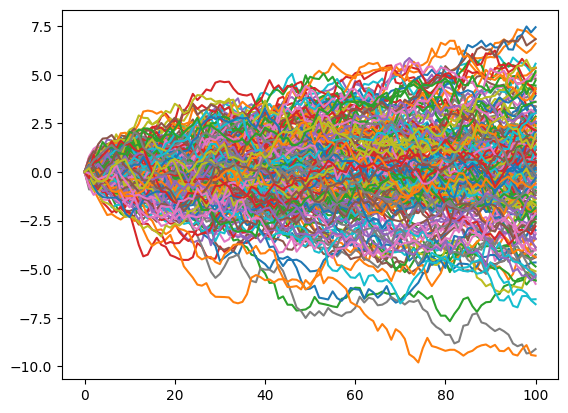

In [962]:
n = 10000
N = 100
T = 10
torch.manual_seed(5)
np.random.seed(5)
W = np.zeros(shape=(N+1,n))
dt = T/N
for t in range(1,N+1):
    W[t,:] = W[t-1,:]+np.sqrt(dt)*np.random.normal(0,1,size=(n))

plt.plot(W[:,1:200])
plt.show()


In [963]:
print(W.shape)

(101, 10000)


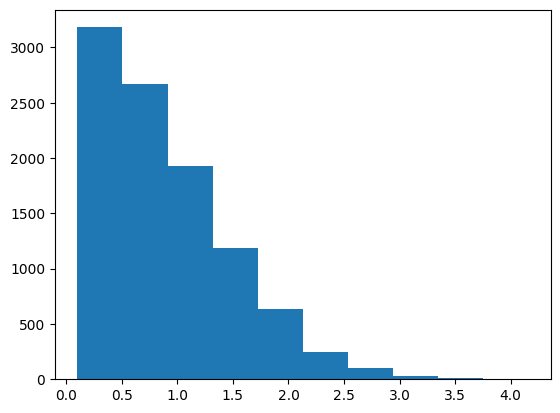

In [964]:
s = np.abs(np.random.normal(0,1,size=(n)))+0.1
plt.hist(s[:])
plt.show()

In [965]:
print(s.shape)

(10000,)


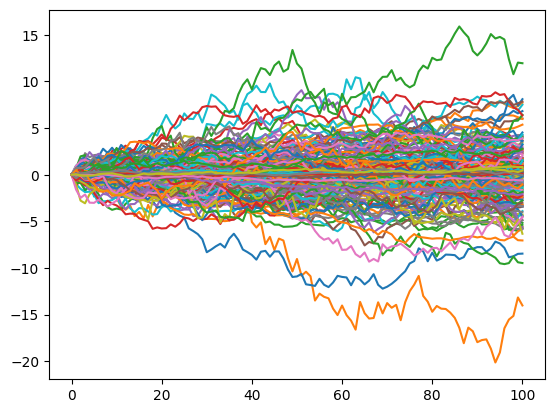

In [966]:
X = s*W
plt.plot(X[:,1:200])
plt.show()

In [967]:
print(X.shape)

(101, 10000)


In [968]:
dX = np.diff(X,n=1,axis=0)

In [969]:
print(dX.shape)

(100, 10000)


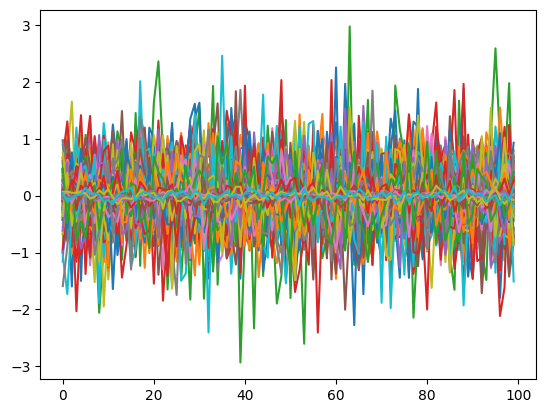

In [970]:
plt.plot(dX[:,0:200])
plt.show()

In [971]:
X_train,Y_train = torch.tensor(dX[:,0:7000]),torch.tensor(s[0:7000])
X_val,Y_val = torch.tensor(dX[:,7000:8000]),torch.tensor(s[7000:8000])
X_test,Y_test = torch.tensor(dX[:,8000:]),torch.tensor(s[8000:])

In [972]:
print(X_train.shape)
print(Y_train.shape)

torch.Size([100, 7000])
torch.Size([7000])


In [973]:
model = torch.nn.Sequential(
    torch.nn.Linear(N,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1)
).double()

In [974]:
print(model)

Sequential(
  (0): Linear(in_features=100, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=512, bias=True)
  (3): ReLU()
  (4): Linear(in_features=512, out_features=1, bias=True)
)


In [975]:
epochs = 100
batch_size = 32
# opt = torch.optim.Adam(model.parameters())

for p in model[:-1].parameters():
    p.requires_grad = False

opt = torch.optim.Adam(model[-1].parameters(), lr=1e-3)
Loss = torch.nn.MSELoss()

In [976]:
# L_train = np.zeros(shape=epochs)
# L_val = np.zeros(shape=epochs)
# for _ in range(epochs):
#     model.train()
#     np.random.seed()
#     for i in np.random.choice(X_train.shape[1],size=batch_size,replace=False):
#         opt.zero_grad()

#         y_hat = model(X_train[:,i])
#         l =  Loss(y_hat,Y_train[i])
#         l.backward()
#         opt.step()
#         L_train[_] += (l/batch_size).detach()

#     model.eval()
#     with torch.no_grad():
#         for i in range(X_val.shape[1]):
#             y_hat = model(X_val[:,i])
#             l =  Loss(y_hat,Y_val[i])
#             L_val[_] += (l/X_val.shape[1]).detach()

        
#     if _ % 5 == 0:
#         print(f"Epoch: {_}, Train loss: {L_train[_]}, Val loss: {L_val[_]}")

In [977]:
features = model[:-1]
head = model[-1]

features.eval()
with torch.no_grad():
    H_train = features(X_train.T)
    H_val = features(X_val.T)

L_train = np.zeros(shape=epochs)
L_val = np.zeros(shape=epochs)

for _ in range(epochs):
    head.train()
    np.random.seed()

    for i in np.random.choice(
        H_train.shape[0], size=batch_size, replace=False
    ):
        opt.zero_grad()

        y_hat = head(H_train[i])
        l = Loss(y_hat, Y_train[i])
        l.backward()
        opt.step()

        L_train[_] += (l / batch_size).detach()

    head.eval()
    with torch.no_grad():
        for i in range(H_val.shape[0]):
            y_hat = head(H_val[i])
            l = Loss(y_hat, Y_val[i])
            L_val[_] += (l / H_val.shape[0]).detach()

    if _ % 5 == 0:
        print(
            f"Epoch: {_}, Train loss: {L_train[_]}, "
            f"Val loss: {L_val[_]}"
        )

Epoch: 0, Train loss: 0.9860774903872497, Val loss: 0.5597233760302404
Epoch: 5, Train loss: 0.0722532273313945, Val loss: 0.040882649715128797
Epoch: 10, Train loss: 0.01965319820617846, Val loss: 0.03422214680781429
Epoch: 15, Train loss: 0.023345277927738994, Val loss: 0.028283570739800177
Epoch: 20, Train loss: 0.021841707149928655, Val loss: 0.022614654053241822
Epoch: 25, Train loss: 0.013139362603583124, Val loss: 0.020156135752982998
Epoch: 30, Train loss: 0.024323339688701266, Val loss: 0.02109481563105768
Epoch: 35, Train loss: 0.011053711544049315, Val loss: 0.016182457769693948
Epoch: 40, Train loss: 0.010758908084950223, Val loss: 0.016379423954245655
Epoch: 45, Train loss: 0.01999861419127258, Val loss: 0.015025066438927887
Epoch: 50, Train loss: 0.011743571149859586, Val loss: 0.01621675723548657
Epoch: 55, Train loss: 0.011492534987891712, Val loss: 0.015240454064890704
Epoch: 60, Train loss: 0.02332796865368083, Val loss: 0.015681509557317837
Epoch: 65, Train loss: 0.0

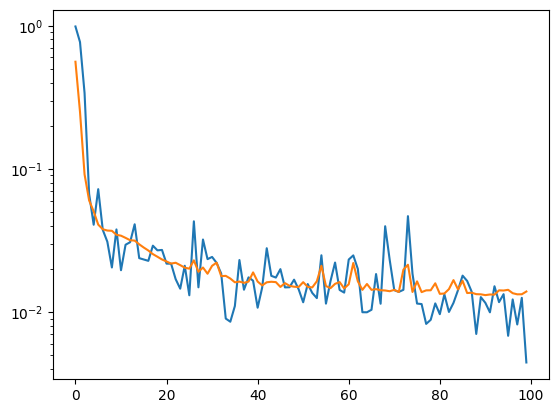

In [978]:
plt.plot(L_train)
plt.plot(L_val)
plt.yscale("log")
plt.show()

In [979]:
def evaluate(X, Y):
    model.eval()
    with torch.no_grad():
        return Loss(model(X.T).squeeze(), Y).item()

print(evaluate(X_val, Y_val), evaluate(X_test, Y_test))

0.013957726687120645 0.015419346460603901


In [980]:
model.eval()
with torch.no_grad():
    test = model(X_test.T).squeeze(-1).cpu().numpy()

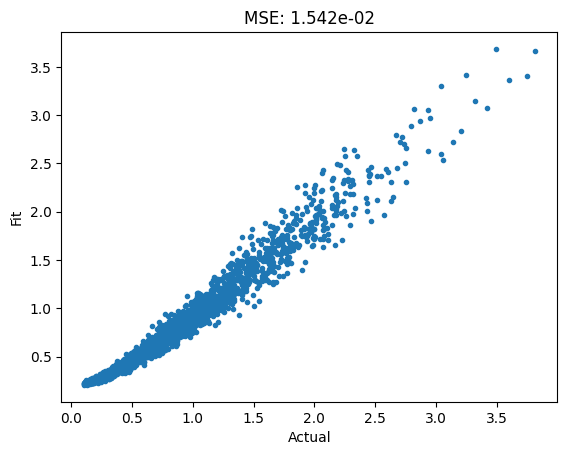

In [981]:
plt.plot(Y_test.detach(),test,'.')
plt.title(f"MSE: {(evaluate(X_test, Y_test)):.3e}")
plt.xlabel("Actual")
plt.ylabel("Fit")
plt.show()
